En este cuaderno probaremos diversas normalizaciones junto al modelo basado en Redes neuronales Densas.
Primero cargamos los datos que usaremos.

In [4]:
import os

os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

import numpy as np
from pathlib import Path

processed_path = Path("../data/splits/2026-08-16_processed_data_no_duplicates.npz")

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [5]:
# Datos de entrada Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos objetivo SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

Probamos ahora una normalización basada en la media aritmética de todos los espectros observados en el conjunto de entrenamiento. 

In [6]:
# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm_global = (X_train - X_mean) / X_std
X_val_norm_global = (X_val - X_mean) / X_std
X_test_norm_global = (X_test - X_mean) / X_std

y_train_norm_global = (y_train - y_mean) / y_std
y_val_norm_global = (y_val - y_mean) / y_std
y_test_norm_global = (y_test - y_mean) / y_std

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt

n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

# Definimos el modelo a usar
model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta = 1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

Entrenamos el modelo

In [9]:
history_norm_global = model.fit(
    X_train_norm_global,
    y_train_norm_global,
    validation_data=(X_val_norm_global, y_val_norm_global),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - loss: 0.0668 - mae: 0.2137 - mse: 0.1600 - val_loss: 0.0149 - val_mae: 0.1022 - val_mse: 0.0319 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - loss: 0.0132 - mae: 0.0930 - mse: 0.0278 - val_loss: 0.0124 - val_mae: 0.0889 - val_mse: 0.0271 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - loss: 0.0117 - mae: 0.0891 - mse: 0.0252 - val_loss: 0.0118 - val_mae: 0.0894 - val_mse: 0.0259 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - loss: 0.0110 - mae: 0.0862 - mse: 0.0242 - val_loss: 0.0109 - val_mae: 0.0866 - val_mse: 0.0239 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - loss: 0.0110 - mae: 0.0860 - mse: 0.0236 - val_loss: 0.0123 - val_mae: 0.0877 - val_mse: 0.0270 - learning_rate: 1.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - loss: 0.0104 - mae: 0.0839 - mse: 0.0228 - v

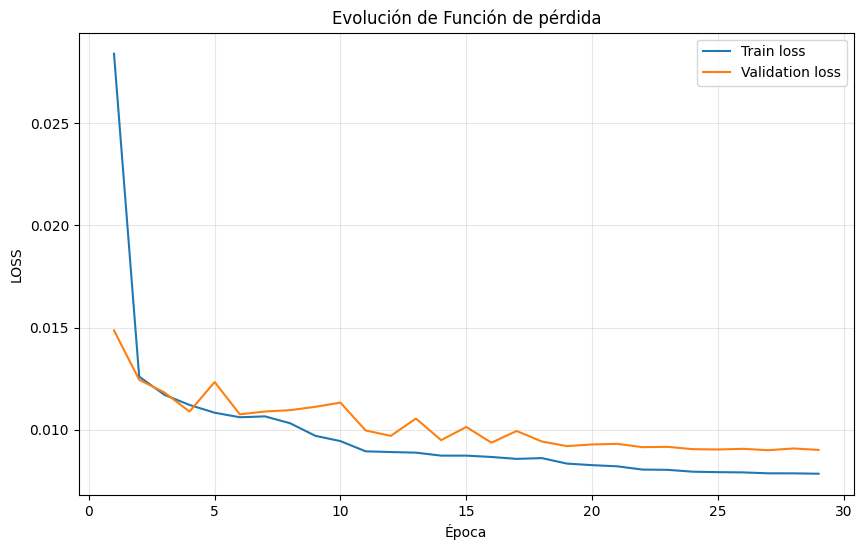

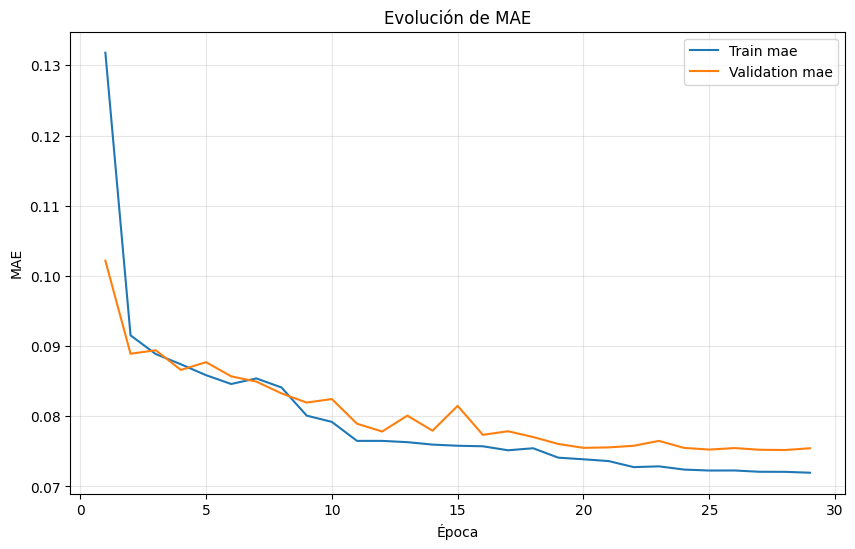

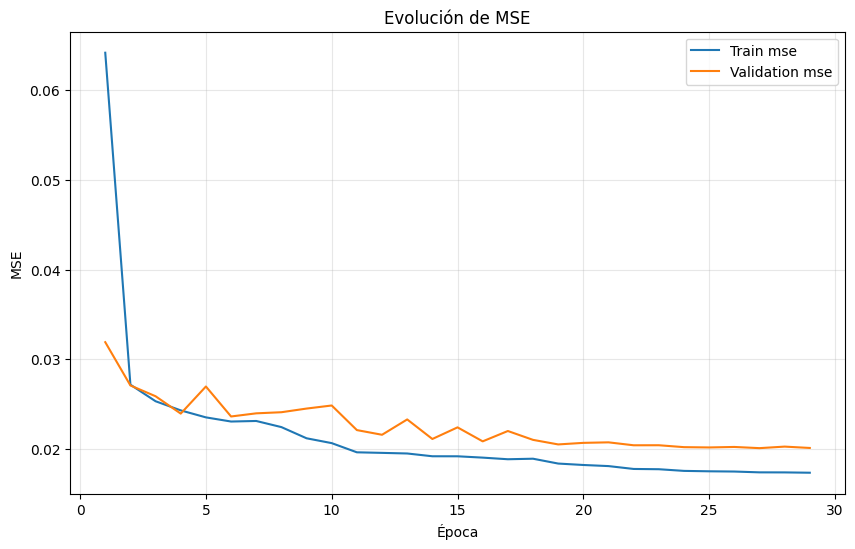

In [10]:
model_data_norm_global = history_norm_global.history
epochs = range(1, len(model_data_norm_global["loss"]) + 1)

metrics = [
    ("loss", "Función de pérdida"),
    ("mae", "MAE"),
    ("mse", "MSE")
]

for metric, title in metrics:
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, model_data_norm_global[metric], label=f"Train {metric}")
    plt.plot(epochs, model_data_norm_global[f"val_{metric}"], label=f"Validation {metric}")

    plt.xlabel("Época")
    plt.ylabel(metric.upper())
    plt.title(f"Evolución de {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [11]:
# Predecimos y sobre el conjunto de test
y_pred_norm_global = model.predict(X_test_norm_global)
y_pred_global = y_pred_norm_global * y_std + y_mean

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Graficamos un par de ejemplos

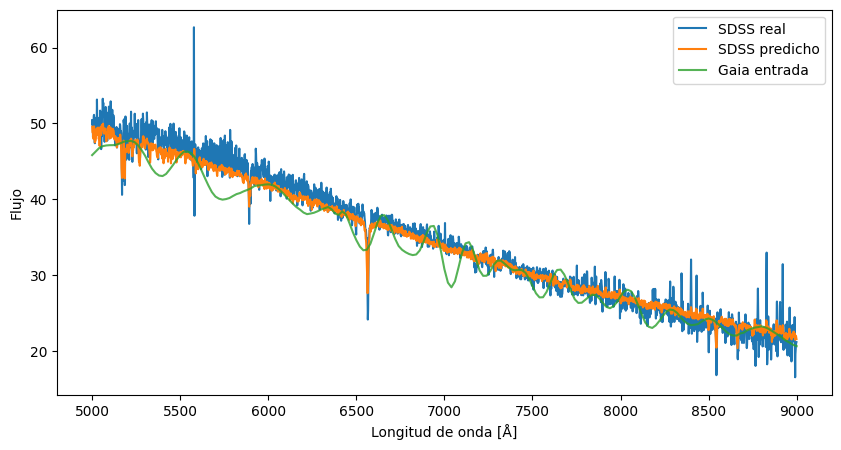

In [12]:
i = 123

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_global[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

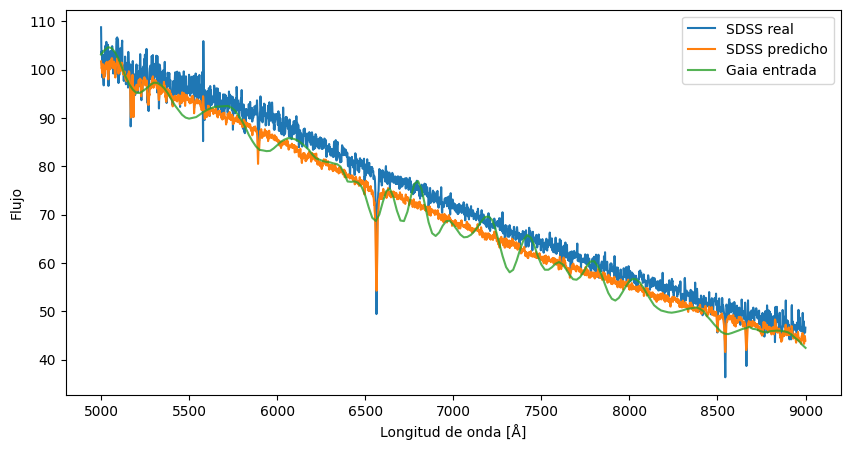

In [13]:
i = 191

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_global[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

In [14]:
test_loss, test_mae, test_mse = model.evaluate(
    X_test_norm_global,
    y_test_norm_global,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0094 - mae: 0.0761 - mse: 0.0210


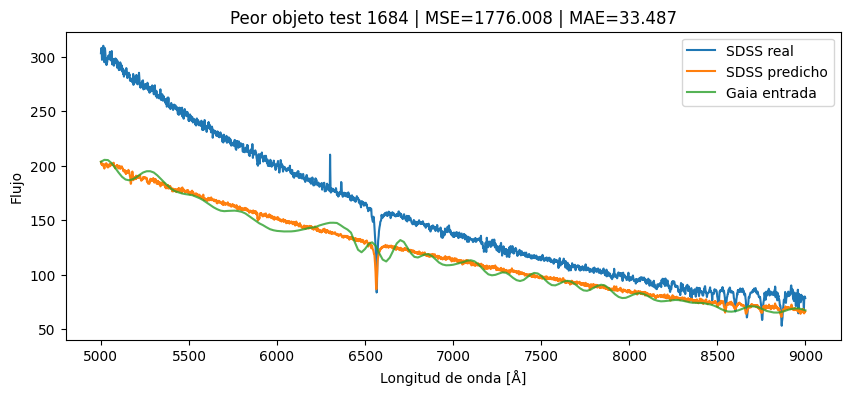

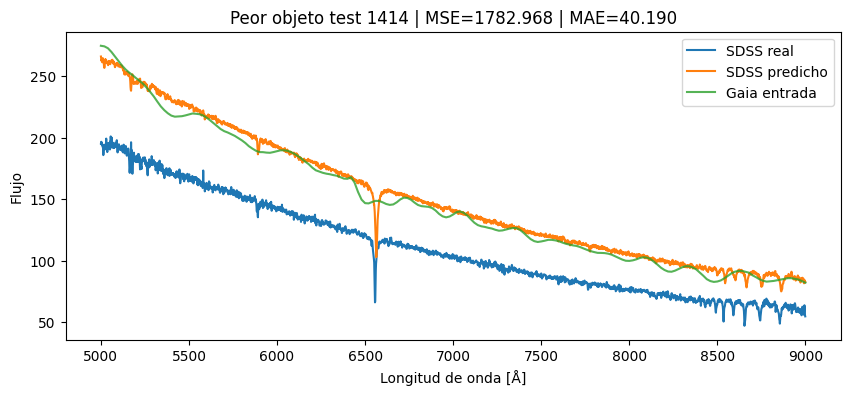

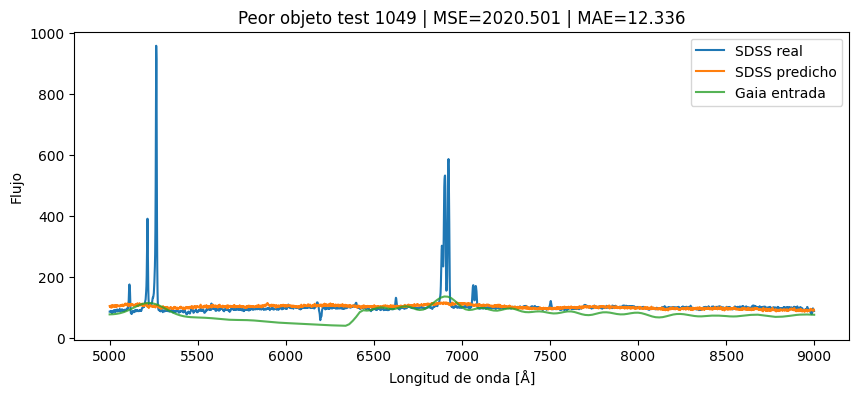

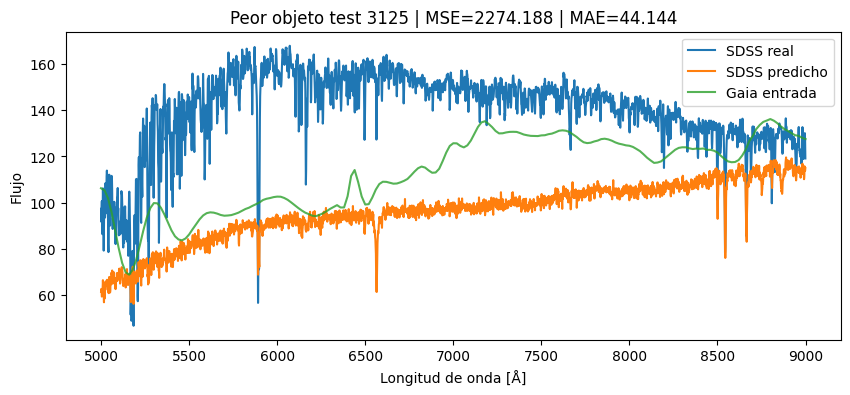

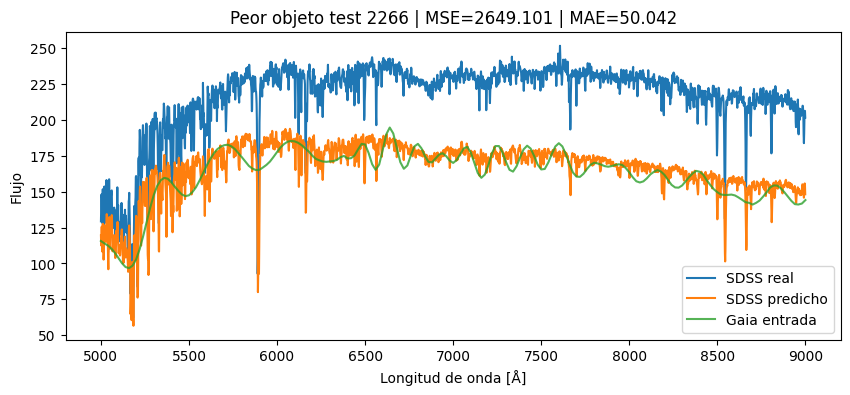

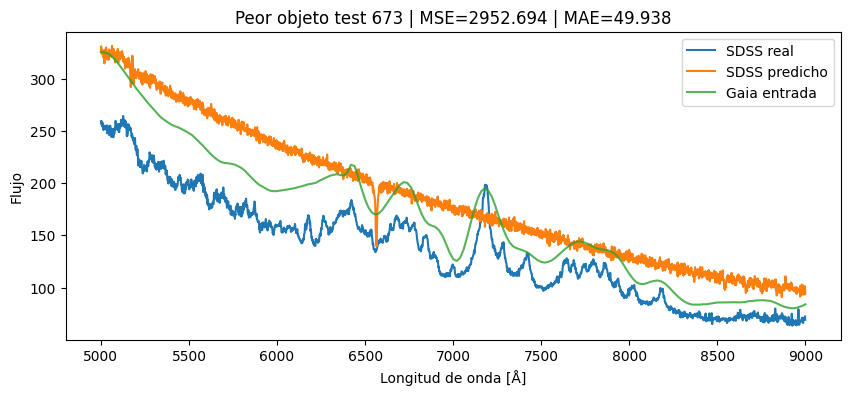

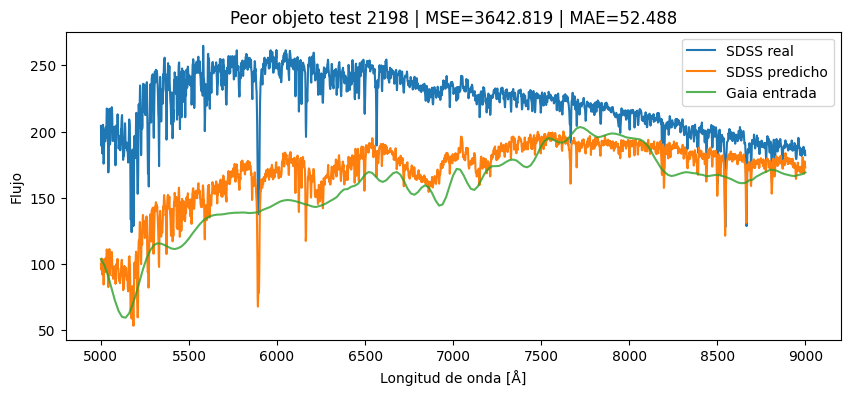

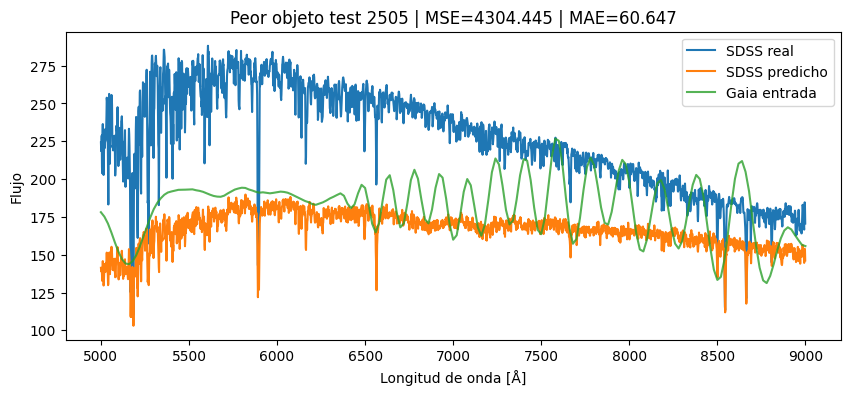

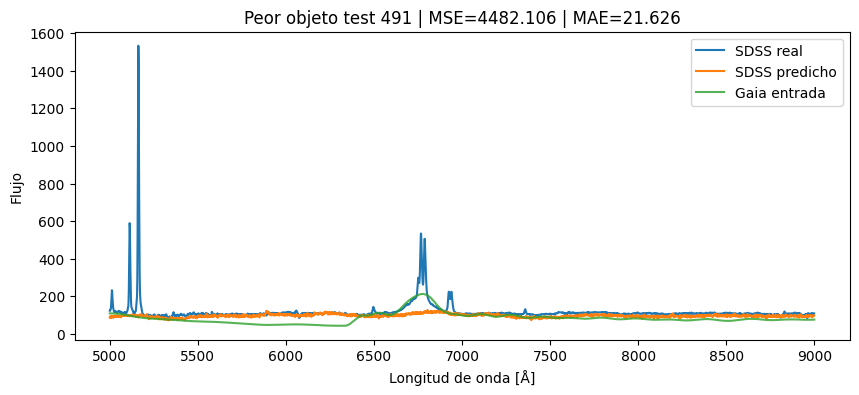

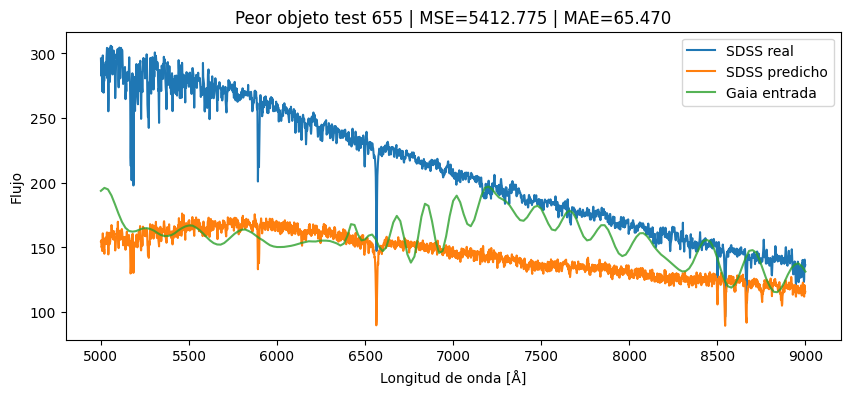

In [15]:
mae = np.mean(np.abs(y_test - y_pred_global))
mse = np.mean((y_test - y_pred_global) ** 2)
rmse = np.sqrt(mse)

mae_per_object = np.mean(np.abs(y_test - y_pred_global), axis=1)
mse_per_object = np.mean((y_test - y_pred_global) ** 2, axis=1)
rmse_per_object = np.sqrt(mse_per_object)

worst_idx = np.argsort(mse_per_object)[-10:]

for i in worst_idx:

    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength, y_pred_global[i], label="SDSS predicho")
    plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Peor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

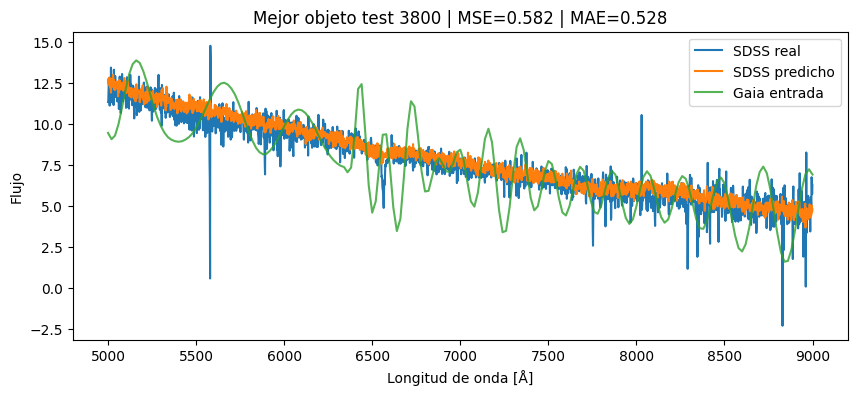

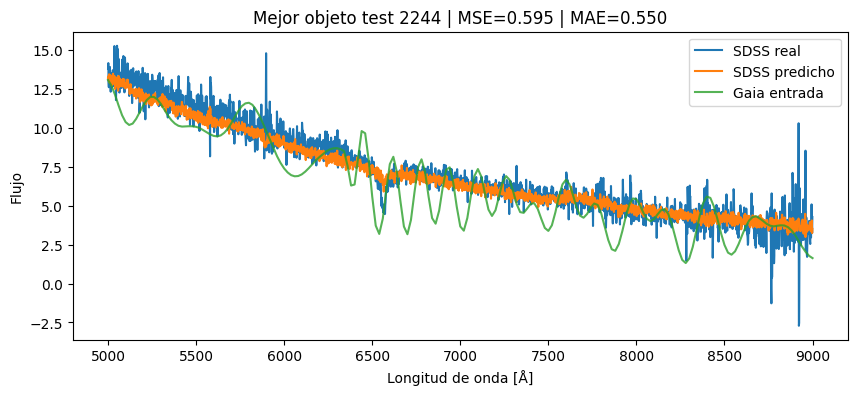

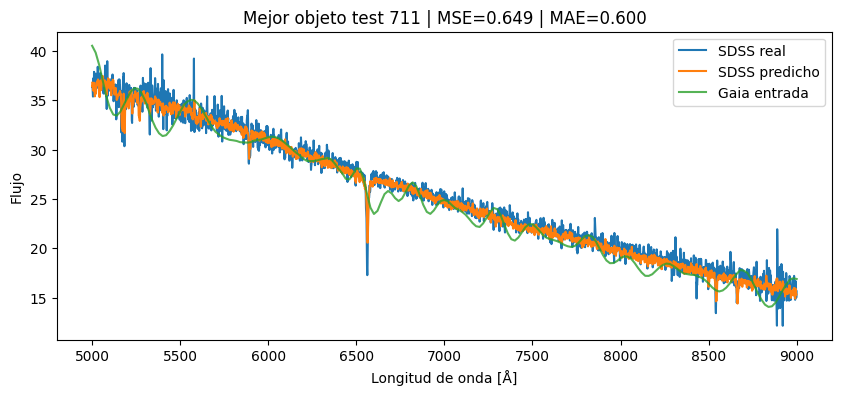

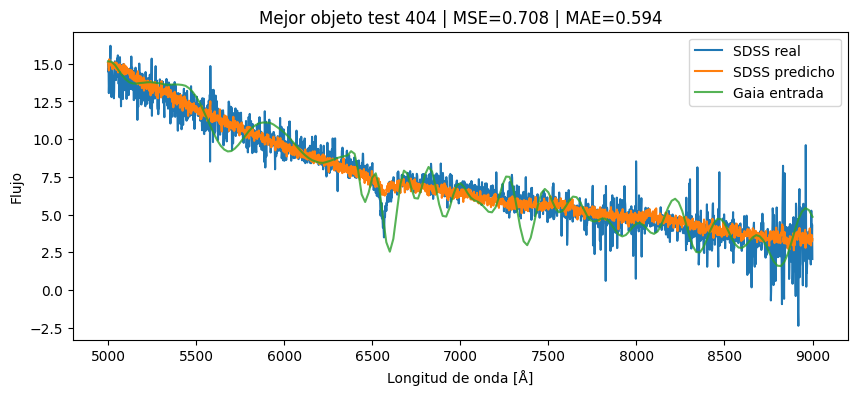

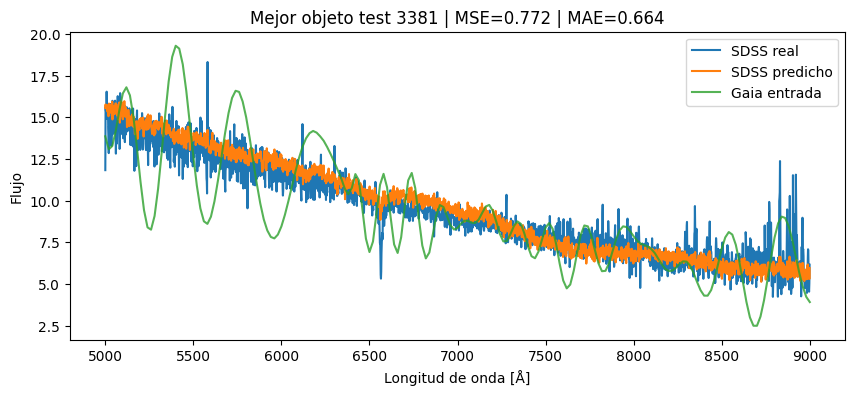

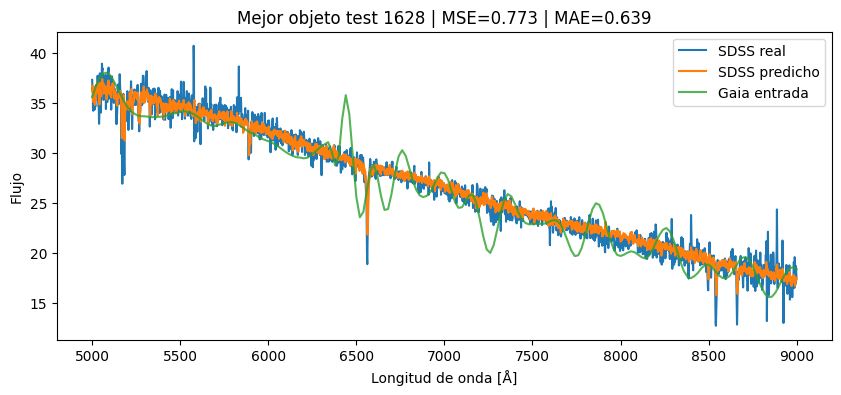

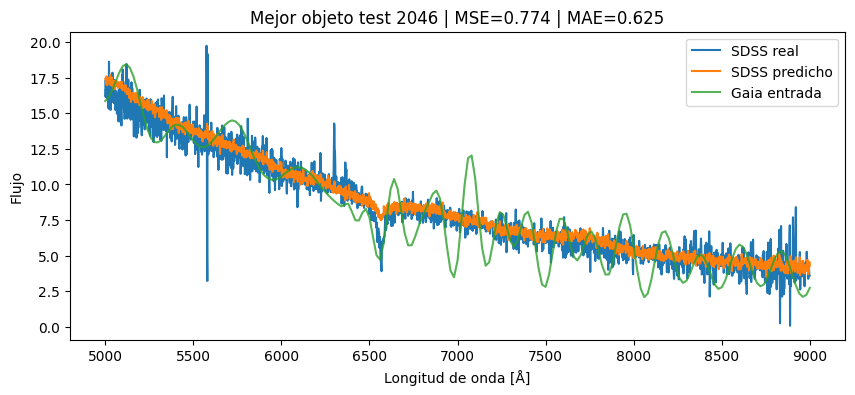

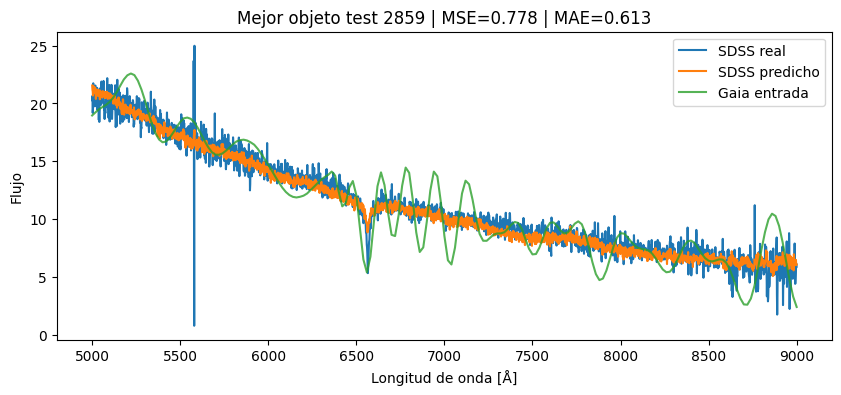

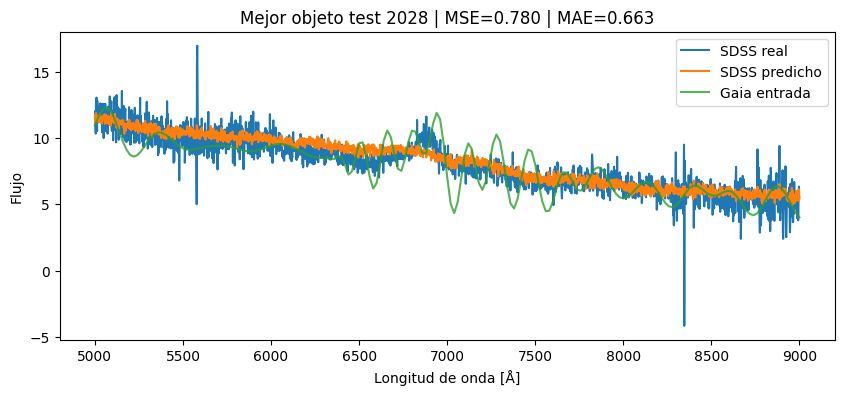

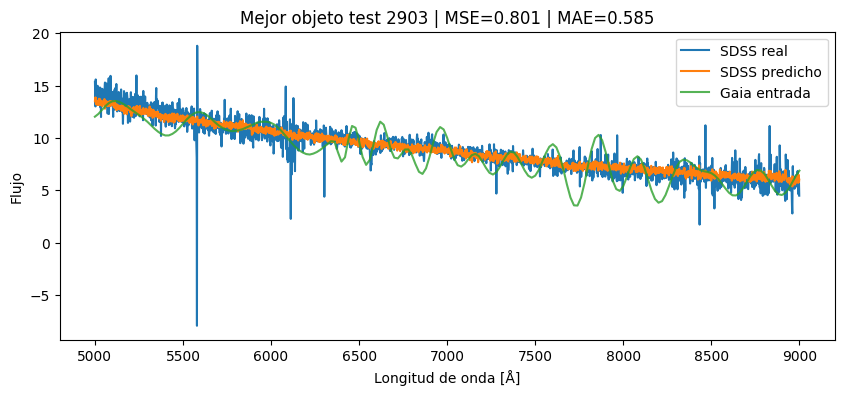

In [16]:
best_idx = np.argsort(mse_per_object)[:10]

for i in best_idx:
    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength, y_pred_global[i], label="SDSS predicho")
    plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Mejor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

Añadimos código para comprobar los valores sacados con iSpec del espectro real y predicho. 

In [17]:
import sys
from pathlib import Path

ISPEC_FUNCTIONS_DIR = Path(
    "/Users/carlasequero/Desktop/trabajo-fin-master/solution/models"
)

if str(ISPEC_FUNCTIONS_DIR) not in sys.path:
    sys.path.insert(0, str(ISPEC_FUNCTIONS_DIR))

In [18]:
# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)

In [19]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# Cargamos Resources
resources = load_ispec_resources()


Recursos de iSpec cargados correctamente.


In [21]:
from astropy.table import Table
# Cargamos la tabla de Gaia guardada en local
gaia_data_table = Table.read(
    "/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/"
    "gaia_data.ecsv",
    format="ascii.ecsv"
)

# Pasamos a dataframe
gaia_data_df = gaia_data_table.to_pandas()

In [22]:
# Analizamos y devolvemos DF con valores ajustados a los espectros
results_df = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_global,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=2
    )

Espectros analizados:   0%|          | 0/2 [00:00<?, ?cuerpos estelares/s]

Only LTE
Only LTE
Only LTE
Only LTE


In [23]:
display(results_df)


,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5357.008345,4.810525,-0.969029,5205.351681,4.660846,-0.840457,-151.656664,-0.149679,0.128571
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5813.224308,4.707357,-1.129837,5823.998308,4.697995,-1.156065,10.773999,-0.009363,-0.026229


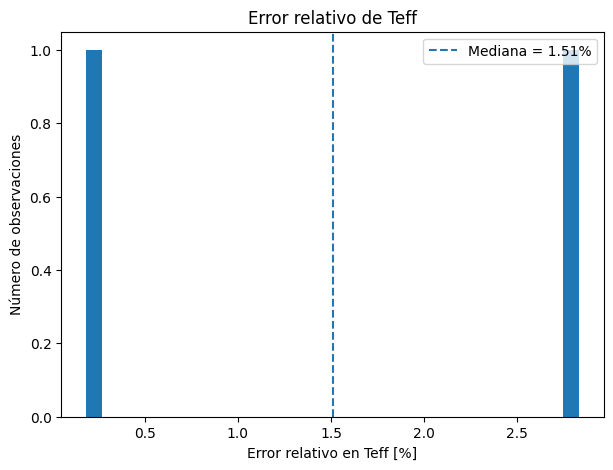

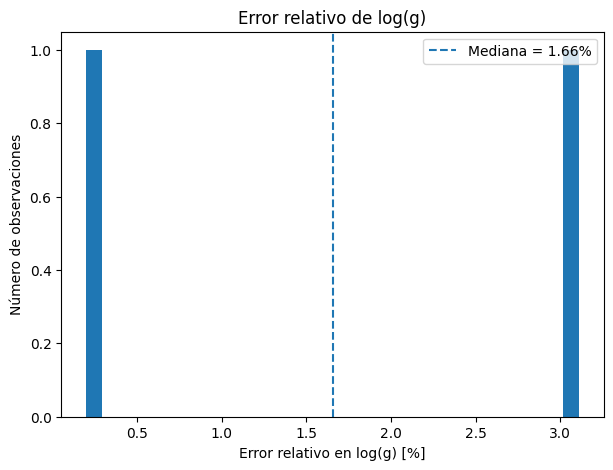

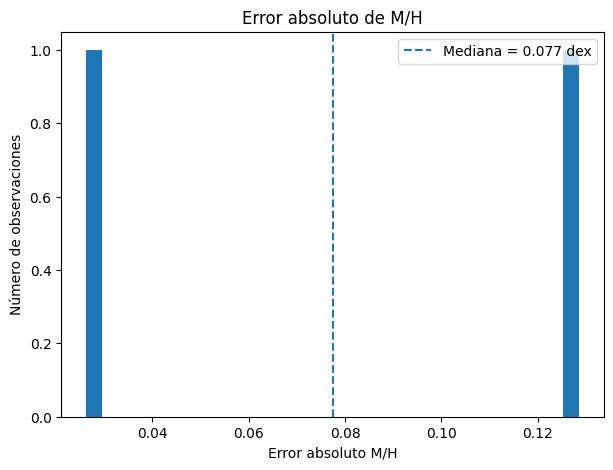

In [24]:
error_df = analyze_ispec_errors(results_df)

In [22]:
display(error_df)

,test_index,source_id,gaia_teff,gaia_logg,gaia_mh,real_teff,real_logg,real_mh,pred_teff,pred_logg,pred_mh,delta_teff,delta_logg,delta_mh,abs_error_teff,abs_error_logg,abs_error_mh,rel_error_teff,rel_error_logg
0,63,152047619011614592,5181.031738,4.6678,-0.8967,5357.008345,4.810525,-0.969029,5212.952443,4.650169,-0.842119,-144.055902,-0.160356,0.126910,144.055902,0.160356,0.126910,2.689111,3.333447
1,3594,1297820202093665792,5753.429688,4.6788,-1.1166,5813.224308,4.707357,-1.129837,5817.259907,4.703049,-1.116263,4.035598,-0.004309,0.013574,4.035598,0.004309,0.013574,0.069421,0.091530


Intentamos el mismo modelo pero con normalización espectro a espectro con la mediana.

In [23]:
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

y_scale_train = np.nanmedian(np.abs(y_train), axis=1, keepdims=True)
y_scale_val = np.nanmedian(np.abs(y_val), axis=1, keepdims=True)
y_scale_test = np.nanmedian(np.abs(y_test), axis=1, keepdims=True)

X_train_norm_median_spec = X_train / X_scale_train
X_val_norm_median_spec = X_val / X_scale_val
X_test_norm_median_spec = X_test / X_scale_test

y_train_norm_median_spec = y_train / y_scale_train
y_val_norm_median_spec = y_val / y_scale_val
y_test_norm_median_spec = y_test / y_scale_test

In [24]:
n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model_median_spec = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_median_spec.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_median_spec.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Entrenamos el modelo
history = model_median_spec.fit(
    X_train_norm_median_spec,
    y_train_norm_median_spec,
    validation_data=(X_val_norm_median_spec, y_val_norm_median_spec),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - loss: 0.0662 - mae: 0.1952 - mse: 0.1543 - val_loss: 0.0051 - val_mae: 0.0581 - val_mse: 0.0152 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - loss: 0.0047 - mae: 0.0532 - mse: 0.0120 - val_loss: 0.0043 - val_mae: 0.0491 - val_mse: 0.0134 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - loss: 0.0043 - mae: 0.0498 - mse: 0.0116 - val_loss: 0.0047 - val_mae: 0.0532 - val_mse: 0.0141 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - loss: 0.0041 - mae: 0.0498 - mse: 0.0107 - val_loss: 0.0040 - val_mae: 0.0481 - val_mse: 0.0127 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - loss: 0.0039 - mae: 0.0486 - mse: 0.0101 - val_loss: 0.0038 - val_mae: 0.0474 - val_mse: 0.0123 - learning_rate: 1.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - loss: 0.0039 - mae: 0.0481 - mse: 0.0105 - v

In [26]:
y_pred_norm_median_spec = model_median_spec.predict(X_test_norm_median_spec)
y_pred_median_spec = y_pred_norm_median_spec* y_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [27]:
test_loss_median_spec, test_mae_median_spec, test_mse_median_spec = model_median_spec.evaluate(
    X_test_norm_median_spec,
    y_test_norm_median_spec,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031 - mae: 0.0420 - mse: 0.0088


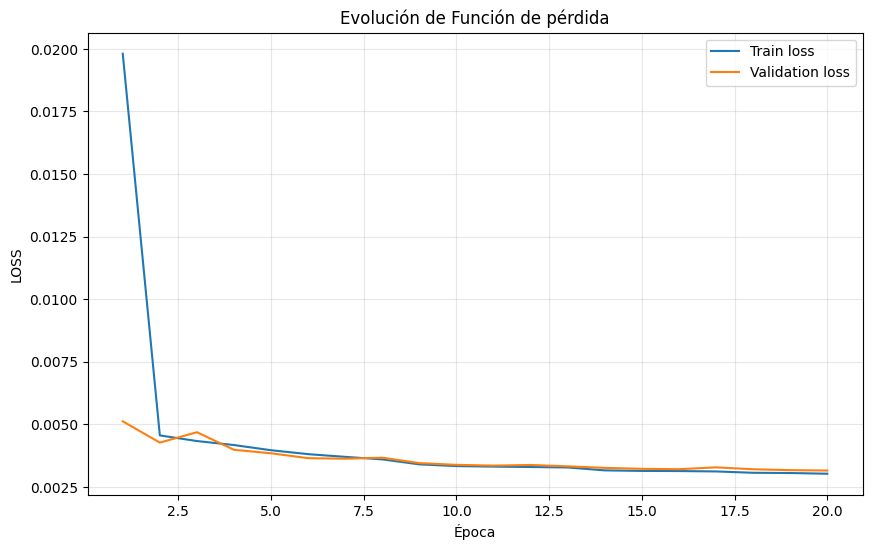

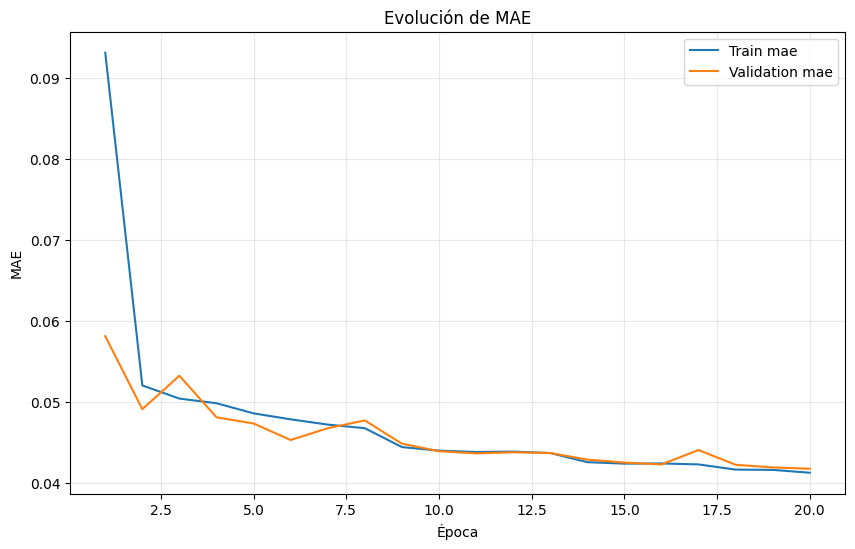

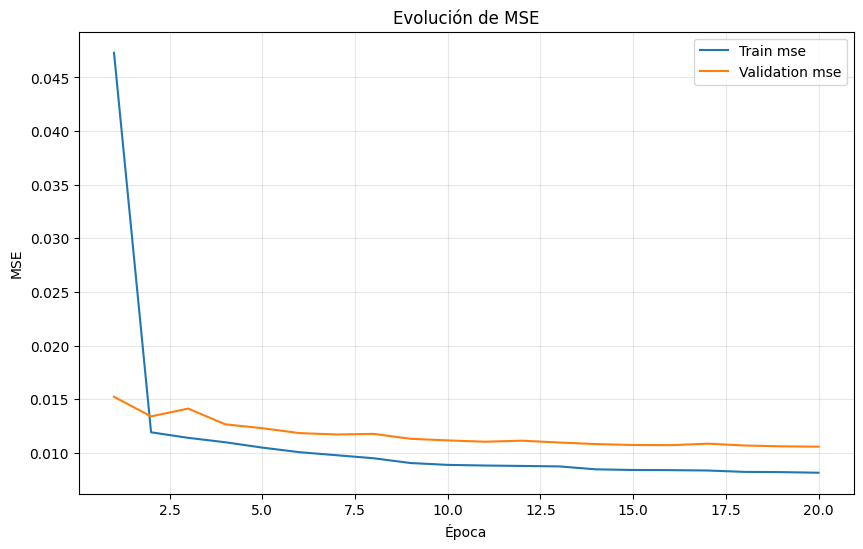

In [28]:
model_data_median_spec = history.history
epochs = range(1, len(model_data_median_spec["loss"]) + 1)

metrics = [
    ("loss", "Función de pérdida"),
    ("mae", "MAE"),
    ("mse", "MSE")
]

for metric, title in metrics:
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, model_data_median_spec[metric], label=f"Train {metric}")
    plt.plot(epochs, model_data_median_spec[f"val_{metric}"], label=f"Validation {metric}")

    plt.xlabel("Época")
    plt.ylabel(metric.upper())
    plt.title(f"Evolución de {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

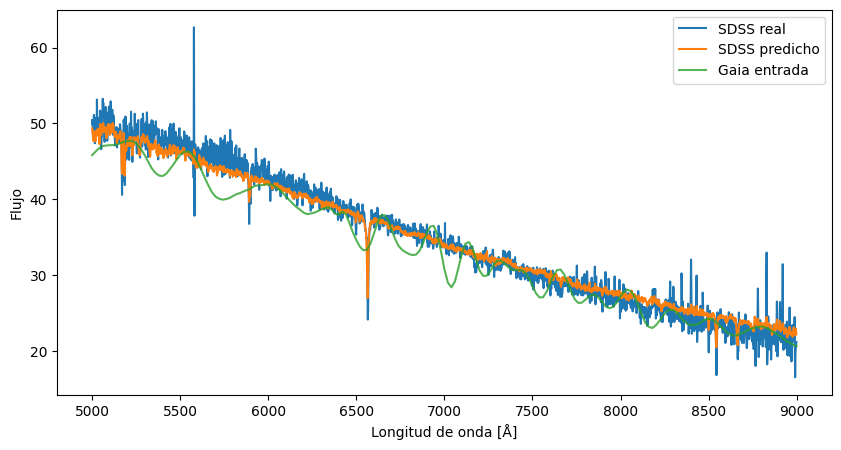

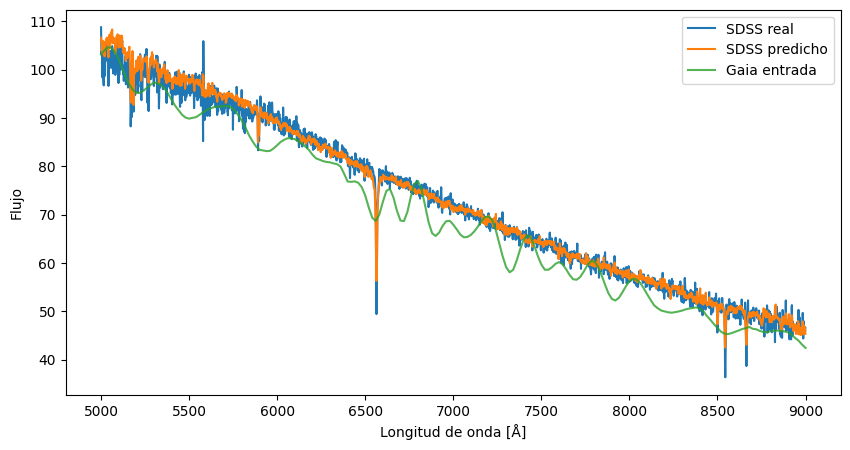

In [29]:
i = 123
#, 23, 178

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_median_spec[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

i = 191

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_median_spec[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

Misma estructura pero con normalización con el máximo por espectro.

In [30]:
# Máximo absoluto por espectro
X_max_train = np.nanmax(np.abs(X_train), axis=1, keepdims=True)
X_max_val = np.nanmax(np.abs(X_val), axis=1, keepdims=True)
X_max_test = np.nanmax(np.abs(X_test), axis=1, keepdims=True)

y_max_train = np.nanmax(np.abs(y_train), axis=1, keepdims=True)
y_max_val = np.nanmax(np.abs(y_val), axis=1, keepdims=True)
y_max_test = np.nanmax(np.abs(y_test), axis=1, keepdims=True)

# Normalización
X_train_norm_max = X_train / X_max_train
X_val_norm_max = X_val / X_max_val
X_test_norm_max = X_test / X_max_test

y_train_norm_max = y_train / y_max_train
y_val_norm_max = y_val / y_max_val
y_test_norm_max = y_test / y_max_test

In [31]:
model_per_spectrum_max = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_per_spectrum_max.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_per_spectrum_max.summary()

history_max_spectrum = model_per_spectrum_max.fit(
    X_train_norm_max,
    y_train_norm_max,
    validation_data=(X_val_norm_max, y_val_norm_max),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 37s 70ms/step - loss: 0.0265 - mae: 0.1461 - mse: 0.0530 - val_loss: 0.0056 - val_mae: 0.0769 - val_mse: 0.0112 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 35s 68ms/step - loss: 0.0053 - mae: 0.0707 - mse: 0.0106 - val_loss: 0.0059 - val_mae: 0.0692 - val_mse: 0.0118 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 40s 79ms/step - loss: 0.0051 - mae: 0.0694 - mse: 0.0102 - val_loss: 0.0051 - val_mae: 0.0668 - val_mse: 0.0101 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 39s 74ms/step - loss: 0.0049 - mae: 0.0675 - mse: 0.0097 - val_loss: 0.0050 - val_mae: 0.0655 - val_mse: 0.0100 - learning_rate: 1.0000e-04
Epoch 5/50
510/511 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0047 - mae: 0.0663 - mse: 0.0094
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
511/511 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - loss: 0.0047 - mae: 0.0663 - mse: 0.0094 - val_loss: 0.0054 - v

In [32]:
y_pred_norm_max = model_per_spectrum_max.predict(X_test_norm_max)
y_pred_per_spectrum_max = y_pred_norm_max * y_max_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [33]:
test_loss_per_spectrum_max, test_mae_per_spectrum_max, test_mse_per_spectrum_max = model_per_spectrum_max.evaluate(
    X_test_norm_max,
    y_test_norm_max,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0049 - mae: 0.0643 - mse: 0.0098


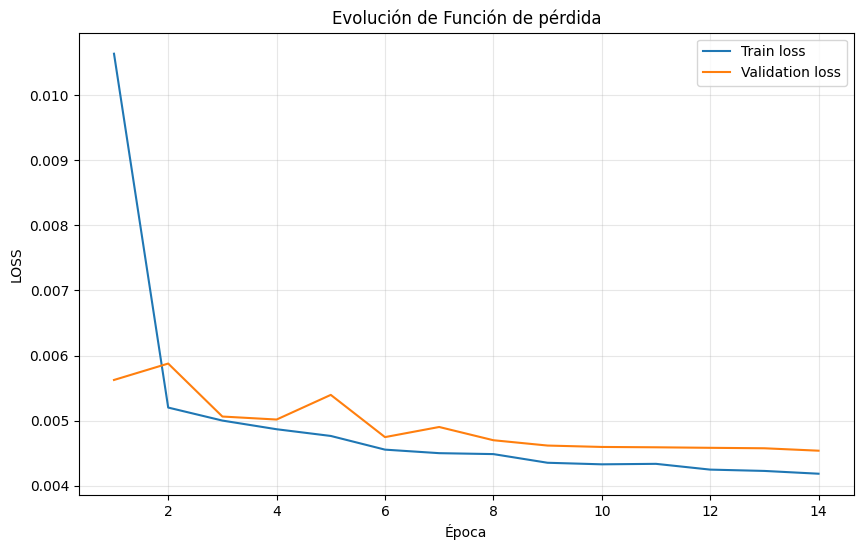

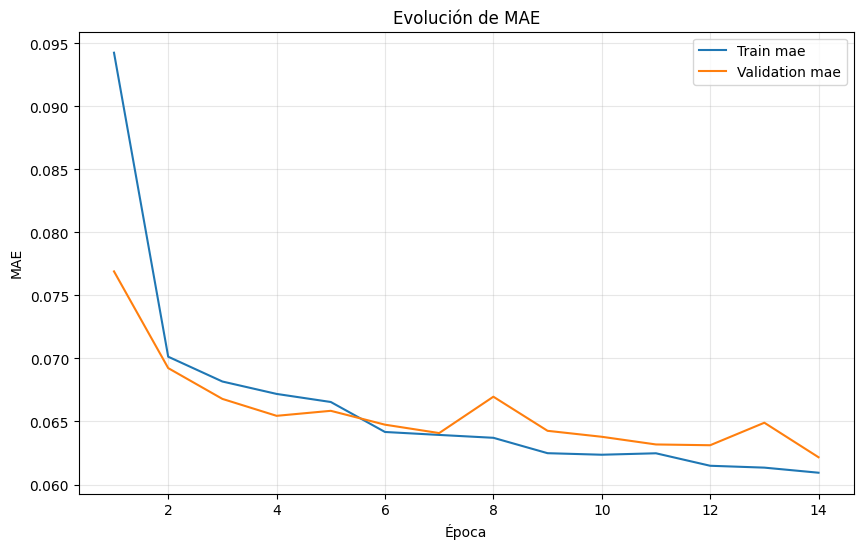

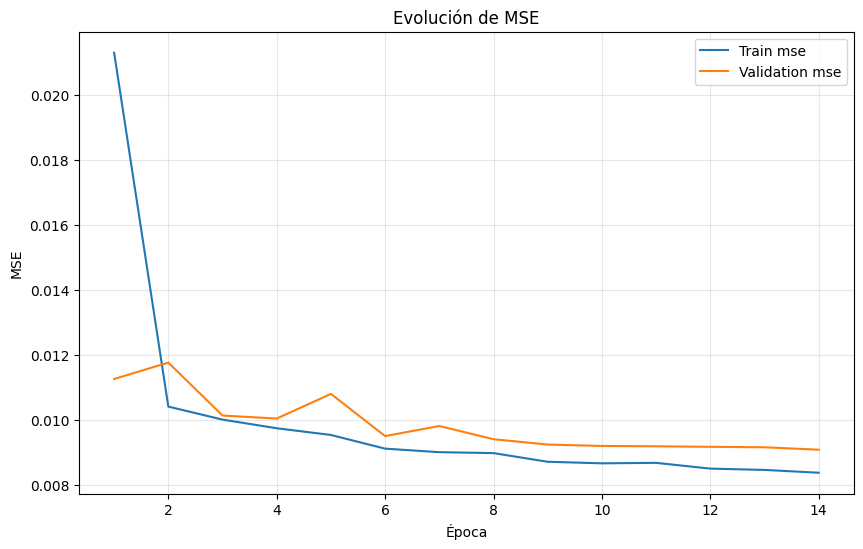

In [34]:
model_data_max = history_max_spectrum.history
epochs = range(1, len(model_data_max["loss"]) + 1)

metrics = [
    ("loss", "Función de pérdida"),
    ("mae", "MAE"),
    ("mse", "MSE")
]

for metric, title in metrics:
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, model_data_max[metric], label=f"Train {metric}")
    plt.plot(epochs, model_data_max[f"val_{metric}"], label=f"Validation {metric}")

    plt.xlabel("Época")
    plt.ylabel(metric.upper())
    plt.title(f"Evolución de {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

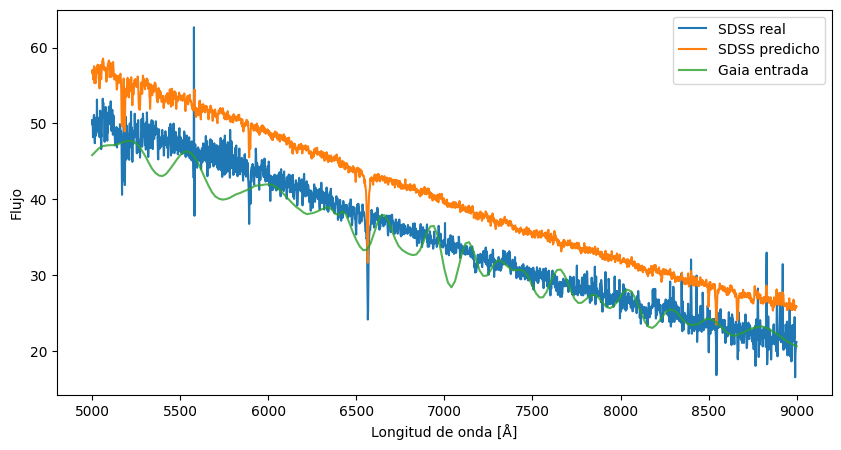

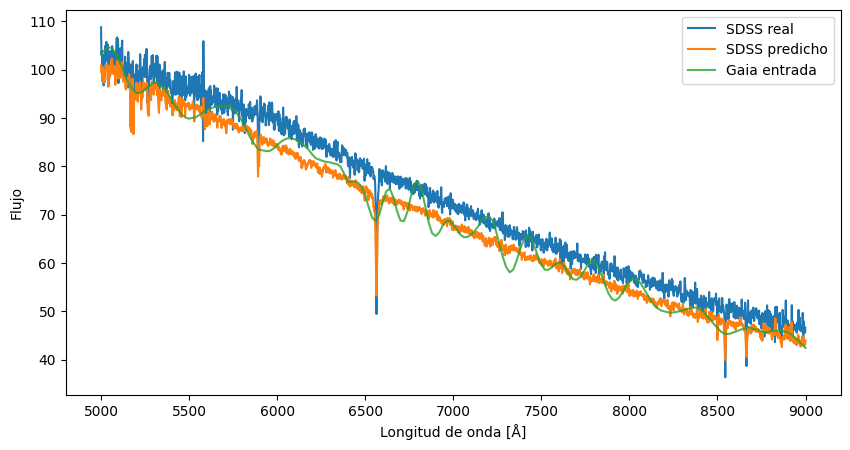

In [35]:
i = 123

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_per_spectrum_max[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

i = 191

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred_per_spectrum_max[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

Probamos un modelo diferente par capas convolucionales

In [36]:
n_gaia = X_train_norm.shape[1]
n_sdss = y_train_norm.shape[1]

# Para Conv1D necesitamos forma (n_objetos, n_puntos, canales)
X_train_cnn = X_train_norm[..., None]
X_val_cnn = X_val_norm[..., None]
X_test_cnn = X_test_norm[..., None]

model_cnn = models.Sequential([
    layers.Input(shape=(n_gaia, 1)),

    layers.Conv1D(32, kernel_size=7, padding="same", activation="elu"),
    layers.Conv1D(64, kernel_size=7, padding="same", activation="elu"),
    layers.Conv1D(128, kernel_size=5, padding="same", activation="elu"),

    layers.Flatten(),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_cnn.summary()

NameError: name 'X_train_norm' is not defined

In [ ]:
history = model_cnn.fit(
    X_train_cnn,
    y_train_norm,
    validation_data=(X_val_cnn, y_val_norm),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50


306/306 ━━━━━━━━━━━━━━━━━━━━ 42s 130ms/step - loss: 0.1011 - mae: 0.2689 - mse: 0.3410 - val_loss: 0.0325 - val_mae: 0.1076 - val_mse: 0.1305 - learning_rate: 1.0000e-04
Epoch 2/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - loss: 0.0304 - mae: 0.1092 - mse: 0.1111 - val_loss: 0.0407 - val_mae: 0.1500 - val_mse: 0.1478 - learning_rate: 1.0000e-04
Epoch 3/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - loss: 0.0253 - mae: 0.1028 - mse: 0.0877 - val_loss: 0.0323 - val_mae: 0.1039 - val_mse: 0.1368 - learning_rate: 1.0000e-04
Epoch 4/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0277 - mae: 0.1005 - mse: 0.1062 - val_loss: 0.0298 - val_mae: 0.1041 - val_mse: 0.1175 - learning_rate: 1.0000e-04
Epoch 5/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - loss: 0.0293 - mae: 0.1027 - mse: 0.1102 - val_loss: 0.0283 - val_mae: 0.1007 - val_mse: 0.1152 - learning_rate: 1.0000e-04
Epoch 6/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0254 - mae: 0.0990 - mse: 0.0859 - val_lo

In [ ]:
test_loss, test_mae, test_mse = model_cnn.evaluate(
    X_test_cnn,
    y_test_norm,
    verbose=1
)

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0200 - mae: 0.0879 - mse: 0.0624


In [ ]:
y_pred_norm_cnn = model_cnn.predict(X_test_cnn)
y_pred_cnn = y_pred_norm * y_std + y_mean
y_test_recalculated_cnn = y_test_norm * y_std + y_mean

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


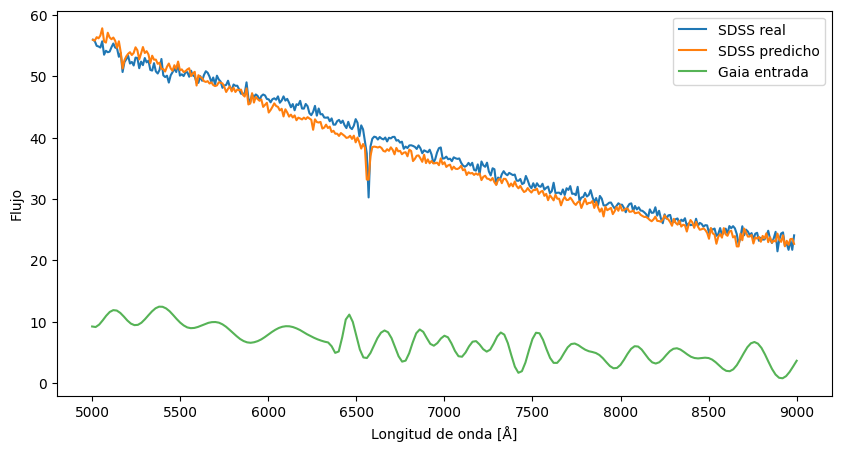

In [ ]:
import matplotlib.pyplot as plt

i = 14

gaia_wavelength_ams = gaia_wavelength * 10
gaia_in_sdss_units_cnn = X_test[i] / 1e-19

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength_binned, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength_binned, y_pred_cnn[i], label="SDSS predicho")
plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()